In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

all_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
all_crawls = ['ny_1', 'texas_1',
              'male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

# all_crawls = ['ny_1',
#               'male_dem_ny_1',
#               'male_rep_ny_1',
#               'female_dem_ny_1',
#               'female_rep_ny_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### Merging and preprocessing

In [4]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():

        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            # if both comments and timestamps files are present
            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:

                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                # this particular comment is just ' '. so adding it manually.
                id_user_mapping = {
                    'DRVQXcWAaaw': 'authoryuccaharris',
                    'DSBZZEcgL4D': 'mafia__460mafia_', 
                    'DSBm_S8gC1p': 'grimreaper3716',
                    'DRYdTZHjT-E': 'danieleichenlaub',
                    'DSARqDnEhPJ': 'amadeoedgardof',
                    'DR_mqpKEr01': 'amadeoedgardof',
                    'DSC60BKkrYV': 'amadeoedgardof',
                    'DR5O3P_jycm': 'dottyeroth',
                    'DSCrwGuDxUR': 'treqpimento_',
                    'DSEn813Eo5Q': 'amadeoedgardof'

                }

                if id_ in id_user_mapping:
                    if id_user_mapping[id_] in comments:
                        idx = comments.index(id_user_mapping[id_])
                        comments = comments[:idx+1] + [' '] + comments[idx+1:]

                # mapping usernames and comments to timestamps
                comments_map = {}

                # checking if comments (username + comment) and timestamps are of same length 
                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes} # TODO: check if likes here is correct
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    # if this happens, its mostly happening since a comment is empty string ''
                    print(f'comemnts-timestamps length mismatch', account, id_, crawl)
            else:
                # only comments file is present
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)
                if len(comments) != 0:
                    if id_ == 'DSC60BKkrYV':
                        caption, comments, likes = None, [], None
                    else:
                        print('no timestamp file and len(comments) != 0', id_, account, crawl, len(comments))
                    
                    # if this happens its usually to do more cleaning of comements

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

In [5]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

ny_1: (1188, 7)
texas_1: (1173, 7)
male_dem_ny_1: (1062, 7)
male_dem_texas_1: (1091, 7)
male_rep_ny_1: (1155, 7)
male_rep_texas_1: (1082, 7)
female_dem_ny_1: (1087, 7)
female_dem_texas_1: (1085, 7)
female_rep_ny_1: (1089, 7)
female_rep_texas_1: (1090, 7)


In [6]:
for crawl, df in dfs.items():
    # df.drop(columns=['likes'], inplace=True, axis=1)
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [7]:
merged_df = dfs['ny_1'].copy()

for crawl, df in dfs.items():
    if crawl == 'ny_1':
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])

texas_1
male_dem_ny_1
male_dem_texas_1
male_rep_ny_1
male_rep_texas_1
female_dem_ny_1
female_dem_texas_1
female_rep_ny_1
female_rep_texas_1


In [8]:
# remove urls that have less than 10 comments

urlids = merged_df['urlid'].unique().tolist()
donotremove_urls = set()
for urlid in urlids:
    temp = merged_df[merged_df['urlid'] == urlid]
    num_rows = temp['comment_num'].max()
    if num_rows <= 8:
        continue
    else:
        donotremove_urls.add(urlid)

merged_df = merged_df[merged_df['urlid'].isin(donotremove_urls)]

In [9]:
# limiting to top 10 comments
merged_df = merged_df[merged_df['comment_num'] <= 9]
merged_df.shape

(860, 23)

In [10]:
temp_df = get_chronological_order_comments(merged_df, all_urls, all_crawls)
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [11]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,comment_num,ny_1_comment,texas_1_comment,male_dem_ny_1_comment,male_dem_texas_1_comment,male_rep_ny_1_comment,male_rep_texas_1_comment,female_dem_ny_1_comment,female_dem_texas_1_comment,female_rep_ny_1_comment,female_rep_texas_1_comment,chronological_comment
0,breitbart,DRWBiQXDG0H,0,"(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(torinejudith, ❤️)","(ryan.smith202, It’s not fissures in MAGA, it ..."
1,breitbart,DRWBiQXDG0H,1,"(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs..."
2,breitbart,DRWBiQXDG0H,2,"(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(scottishlyme, The actual LEFT should be calle...","(scottishlyme, The actual LEFT should be calle...","(terp00, Maga died when trump went Israel firs...","(terp00, Maga died when trump went Israel firs...","(_taco_______, 🤡🤡)"
3,breitbart,DRWBiQXDG0H,3,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T...","(loretta.bauer.35, I thought that was exactly ..."
4,breitbart,DRWBiQXDG0H,4,"(alton_klompus, @wearebreitbart slowly distanc...","(alton_klompus, @wearebreitbart slowly distanc...","(loretta.bauer.35, I thought that was exactly ...","(loretta.bauer.35, I thought that was exactly ...","(loretta.bauer.35, I thought that was exactly ...","(loretta.bauer.35, I thought that was exactly ...","(i_tr00per, Bernie Moreno has the most remedia...","(i_tr00per, Bernie Moreno has the most remedia...","(i_tr00per, Bernie Moreno has the most remedia...","(loretta.bauer.35, I thought that was exactly ...","(torinejudith, ❤️)"


In [12]:
merged_df.shape

(1124, 14)

In [13]:
merged_df.to_csv('merged_data_political.csv', index=False)

### Plotting differences

In [51]:
crawl1 = 'ny_1'
crawl2 = 'texas_1'

temp_df = merged_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, all_urls)

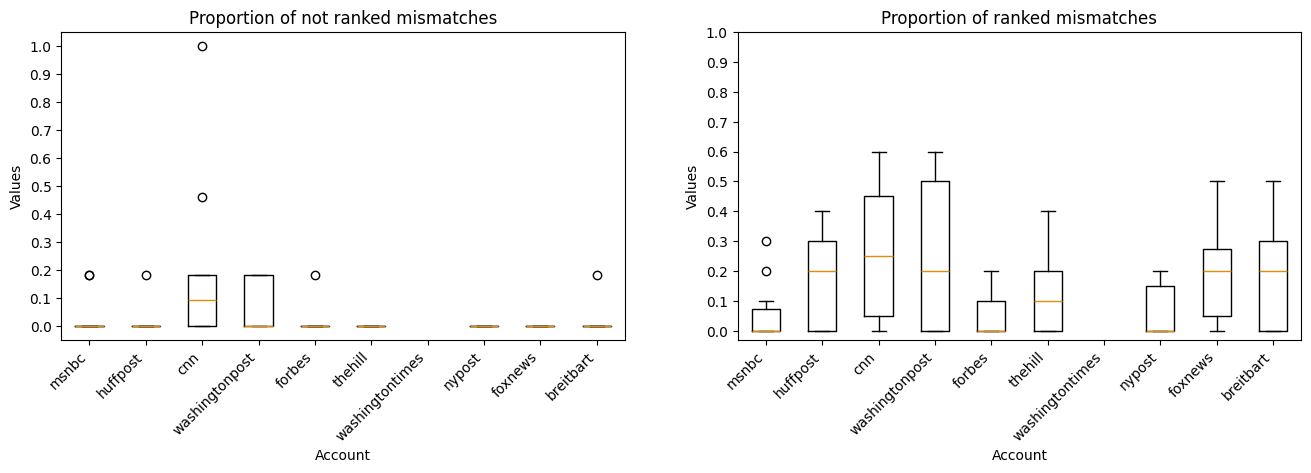

In [52]:
accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

In [ ]:
mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in ['chronological'] + all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = merged_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, all_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

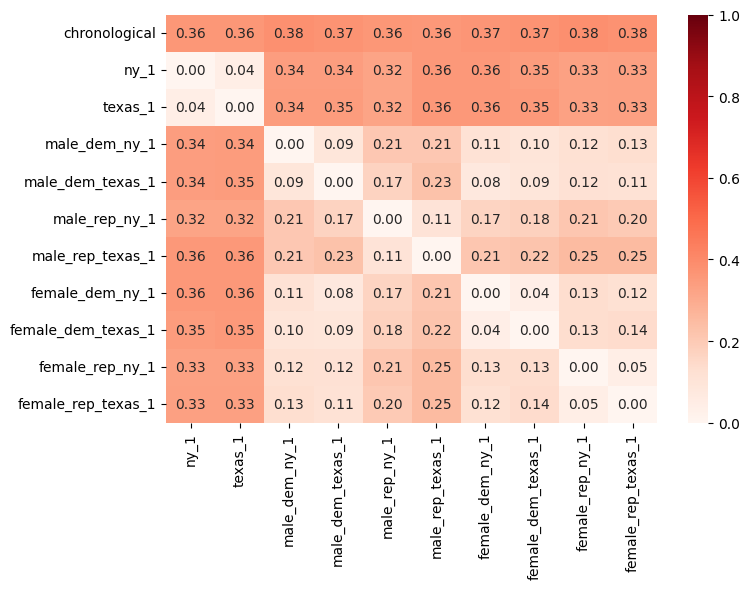

In [54]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(mismatch_no_rank_df, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

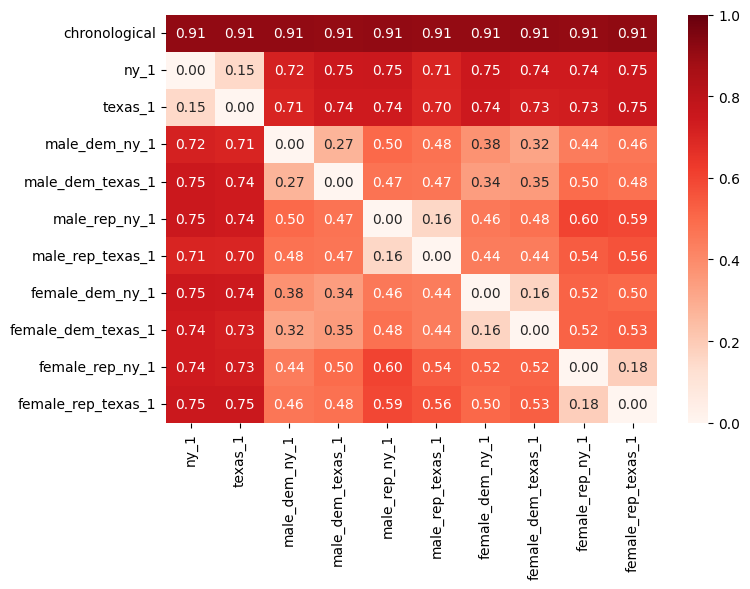

In [55]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(mismatch_rank_df, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

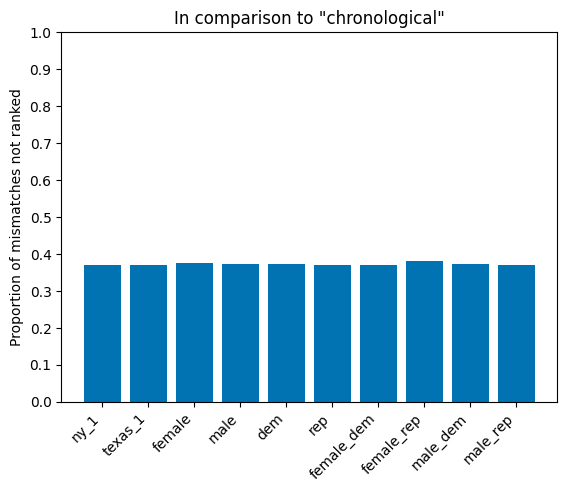

In [18]:
condensed_mismatches_no_rank = {}
individual_labels = ['ny_1', 'texas_1', 'female', 'male', 'dem', 'rep',
                     'female_dem', 'female_rep', 'male_dem', 'male_rep']
base_label = 'chronological'
pattern = r'(?P<gender>male|female)_(?P<ideo>dem|rep)_(?P<loc>ny|texas)'


for x in individual_labels:
    vals = []
    for crawl in ['chronological'] + all_crawls:
        matches = re.search(pattern, crawl)
        groups = matches.groupdict() if matches else {}
        if crawl == 'chronological':
            groups = {'chronological': 'chronological'}
        if base_label in groups.values():
            for label, val in mismatch_no_rank_df.T[crawl].to_dict().items():
                if x in label:
                    vals.append(val)

    try:
        condensed_mismatches_no_rank[x] = sum(vals) / len(vals)
    except ZeroDivisionError:
        condensed_mismatches_no_rank[x] = None


plt.bar(range(len(condensed_mismatches_no_rank)), list(condensed_mismatches_no_rank.values()))
plt.xticks(range(len(condensed_mismatches_no_rank)), list(condensed_mismatches_no_rank.keys()), rotation=45, ha='right')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title(f'In comparison to "{base_label}"')
plt.ylabel('Proportion of mismatches not ranked')
plt.show()

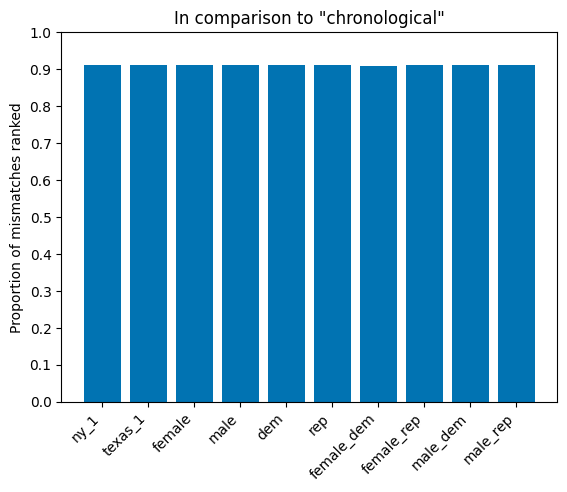

In [19]:
condensed_mismatches_rank = {}
individual_labels = ['ny_1', 'texas_1', 'female', 'male', 'dem', 'rep',
                     'female_dem', 'female_rep', 'male_dem', 'male_rep']
base_label = 'chronological'
pattern = r'(?P<gender>male|female)_(?P<ideo>dem|rep)_(?P<loc>ny|texas)'


for x in individual_labels:
    vals = []
    for crawl in ['chronological'] + all_crawls:
        matches = re.search(pattern, crawl)
        groups = matches.groupdict() if matches else {}
        if crawl == 'chronological':
            groups = {'chronological': 'chronological'}
        if base_label in groups.values():
            for label, val in mismatch_rank_df.T[crawl].to_dict().items():
                if x in label:
                    vals.append(val)

    try:
        condensed_mismatches_rank[x] = sum(vals) / len(vals)
    except ZeroDivisionError:
        condensed_mismatches_rank[x] = None


plt.bar(range(len(condensed_mismatches_rank)), list(condensed_mismatches_rank.values()))
plt.xticks(range(len(condensed_mismatches_rank)), list(condensed_mismatches_rank.keys()), rotation=45, ha='right')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title(f'In comparison to "{base_label}"')
plt.ylabel('Proportion of mismatches ranked')
plt.show()

#### Old graphs

In [20]:
# def aggregate_matrix(group_cols):
#     groups = meta[group_cols].agg("_".join, axis=1) if len(group_cols) > 1 else meta[group_cols[0]]
#     out = pd.DataFrame(index=sorted(groups.unique()),
#                        columns=sorted(groups.unique()),
#                        dtype=float)

#     for a in out.index:
#         ia = groups[groups == a].index
#         for b in out.columns:
#             ib = groups[groups == b].index
#             block = M.loc[ia, ib].to_numpy()

#             if a == b:
#                 mask = ~np.eye(len(ia), len(ib), dtype=bool)
#                 block = block[mask]

#             out.loc[a, b] = np.nanmean(block)

#     return out

# temp_df = mismatch_rank_df.copy()
# pattern = r'(?P<gender>male|female)_(?P<ideo>dem|rep)_(?P<loc>ny|texas)'
# meta = temp_df.index.to_series().str.extract(pattern)

# keep = meta["gender"].notna()
# temp_df = temp_df.loc[keep, keep]
# meta = meta.loc[keep]

# gender_ideology_df = aggregate_matrix(["gender", "ideo"])
# gender_df = aggregate_matrix(["gender"])
# ideology_df = aggregate_matrix(["ideo"])


# sns.heatmap(gender_df, annot=True, cmap="Reds", vmin=0, vmax=1)
# plt.title("Condensed by Gender")
# plt.show()

# sns.heatmap(ideology_df, annot=True, cmap="Reds", vmin=0, vmax=1)
# plt.title("Condensed by Ideology")
# plt.show()

# sns.heatmap(gender_ideology_df, annot=True, cmap="Reds", vmin=0, vmax=1)
# plt.title("Condensed by Gender × Ideology (Location Collapsed)")
# plt.show()

In [21]:
# col1 = 'chronological_comment'
# col2 = 'ny_1_comment'
# col3 = 'texas_1_comment'
# col4 = 'male_dem_ny_1_comment'
# col5 = 'male_dem_texas_1_comment'
# col6 = 'male_rep_ny_1_comment'
# col7 = 'male_rep_texas_1_comment'
# col8 = 'female_dem_ny_1_comment'
# col9 = 'female_dem_texas_1_comment' 
# col10 = 'female_rep_ny_1_comment'
# col11 = 'female_rep_texas_1_comment'

# cols = [col1, col2, col3, col4, col5,
#         col6, col7, col8, col9, col10, col11]

# # col1 = 'chronological_comment'
# # col2 = 'ny_1_comment'
# # col3 = 'male_dem_ny_1_comment'
# # col4 = 'male_rep_ny_1_comment'
# # col5 = 'female_dem_ny_1_comment'
# # col6 = 'female_rep_ny_1_comment'

# # cols = [col1, col2, col3, col4, col5,
# #         col6]


# codes = []
# for idx, x in zip(merged_df.index, zip(*(merged_df[c] for c in cols))):

#     temp_code = []
#     for i, a in enumerate(x):
#         if pd.isna(a):
#             code = -1
#         else:
#             acc_comments = []
            
#             if i == 0:
#                 remove_col = col1
#             elif i == 1:
#                 remove_col = col2
#             elif i == 2:
#                 remove_col = col3
#             elif i == 3:
#                 remove_col = col4
#             elif i == 4:
#                 remove_col = col5
#             elif i == 5:
#                 remove_col = col6
#             elif i == 6:
#                 remove_col = col7
#             elif i == 7:
#                 remove_col = col8
#             elif i == 8:
#                 remove_col = col9
#             elif i == 9:
#                 remove_col = col10
#             elif i == 10:
#                 remove_col = col11

#             for c in cols:
#                 if c == remove_col:
#                     continue
#                 if c == col1:
#                     continue
#                 acc = merged_df.loc[idx, 'account']
#                 url = merged_df.loc[idx, 'urlid']
#                 acc_comments += merged_df[(merged_df['account'] == acc) & (merged_df['urlid'] == url)][c].dropna().unique().tolist() 

#             if a in set(acc_comments):
#                 code = 0
#             else:
#                 code = 1

#         temp_code.append(code)
#     codes.append(temp_code)

# codes = np.array(codes)

# max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
# num_groups = max_code + 1

# base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
# colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
# cmap = ListedColormap(colors)

# bounds = np.arange(-1.5, num_groups + 0.5, 1)
# norm = BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(6, 6))

# sns.heatmap(
#     codes,
#     annot=False,
#     cmap=cmap,
#     norm=norm,
#     vmin=-1,
#     vmax=max_code,
#     cbar=True,                      
#     linewidths=0,
#     yticklabels=False,
#     xticklabels=[c.replace('_comment', '') for c in cols],
#     ax=ax
# )

# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# cbar = ax.collections[0].colorbar
# cbar.set_ticks([-1, 0, 1])
# cbar.set_ticklabels([
#     "-1",
#     "0",
#     "1",
# ])

# # optional: add dotted separators for groups (your urlid trick)
# # indices = merged_df["urlid"].drop_duplicates().index
# # for y in indices:
# #     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

# plt.tight_layout()
# plt.show()


In [22]:
# key_cols = ["account", "urlid"]

# group_comments = {}
# for key, g in merged_df.groupby(key_cols, sort=False):
#     group_comments[key] = {
#         col: set(g[col].dropna())
#         for col in cols
#     }

# overall_not_covered = pd.DataFrame(index=cols, columns=cols, dtype=float)

# for c1 in cols:
#     for c2 in cols:
#         if c1 == c2:
#             overall_not_covered.loc[c1, c2] = 0.0
#             continue

#         total = 0
#         not_covered = 0

#         for key, d in group_comments.items():
#             s1 = d[c1]
#             s2 = d[c2]
#             if not s1:
#                 continue

#             total += len(s1)
#             not_covered += len(s1 - s2)

#         overall_not_covered.loc[c1, c2] = not_covered / total if total else 0.0



# fig, ax = plt.subplots(figsize=(8, 6))

# im = ax.imshow(
#     overall_not_covered.values,
#     aspect='auto',
#     cmap='Reds',
#     vmin=0, vmax=1
# )

# ax.set_xticks(range(len(cols)))
# ax.set_yticks(range(len(cols)))
# ax.set_xticklabels(cols, rotation=45, ha='right')
# ax.set_yticklabels(cols)

# for i in range(len(cols)):
#     for j in range(len(cols)):
#         ax.text(j, i, f"{overall_not_covered.iloc[i, j]:.2f}",
#                 ha='center', va='center', fontsize=8)

# cbar = fig.colorbar(im, ax=ax, cmap='Blues')
# cbar.set_label('Proportion of False (mismatch)')

# plt.tight_layout()
# plt.show()


In [23]:
# codes = []
# for x in zip(*(merged_df[c] for c in cols)):
#     present_already = []
#     temp_code = []
#     for a in x:
#         if pd.isna(a):
#             c = -1
#         else:
#             if a not in present_already:
#                 c = len(present_already)
#                 present_already.append(a)
#             else:
#                 c = present_already.index(a)
#         temp_code.append(c)
#     codes.append(temp_code)

# codes = np.array(codes)

# max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
# num_groups = max_code + 1

# base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
# colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
# cmap = ListedColormap(colors)

# bounds = np.arange(-1.5, num_groups + 0.5, 1)
# norm = BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(6, 6))

# sns.heatmap(
#     codes,
#     annot=False,
#     cmap=cmap,
#     norm=norm,
#     vmin=-1,
#     vmax=max_code,
#     cbar=False,                      
#     linewidths=0,
#     yticklabels=False,
#     xticklabels=[c.replace('_comment', '') for c in cols],
#     ax=ax
# )

# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # optional: add dotted separators for groups (your urlid trick)
# # indices = merged_df["urlid"].drop_duplicates().index
# # for y in indices:
# #     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

# plt.tight_layout()
# plt.show()


In [24]:
# false_ratio = pd.DataFrame(index=cols, columns=cols, dtype=float)

# for c1 in cols:
#     for c2 in cols:
#         if c1 == c2:
#             false_ratio.loc[c1, c2] = 0.0
#         else:
#             comp = merged_df[c1] == merged_df[c2]
#             false_ratio.loc[c1, c2] = (~comp).mean()
#             false_ratio.loc[c2, c1] = false_ratio.loc[c1, c2]


# fig, ax = plt.subplots(figsize=(8, 6))

# im = ax.imshow(
#     false_ratio.values,
#     aspect='auto',
#     cmap='Reds',
#     vmin=0, vmax=1
# )

# ax.set_xticks(range(len(cols)))
# ax.set_yticks(range(len(cols)))
# ax.set_xticklabels(cols, rotation=45, ha='right')
# ax.set_yticklabels(cols)

# for i in range(len(cols)):
#     for j in range(len(cols)):
#         ax.text(j, i, f"{false_ratio.iloc[i, j]:.2f}",
#                 ha='center', va='center', fontsize=8)

# cbar = fig.colorbar(im, ax=ax, cmap='Blues')
# cbar.set_label('Proportion of False (mismatch)')

# plt.tight_layout()
# plt.show()


### Regression Analysis

In [14]:
reg_df = pd.DataFrame(columns=['account', 'urlid', 'gender', 'ideology', 'fcount_no_rank', 'ftrials_no_rank', 'fcount_rank', 'ftrials_rank'])

temp_list = []
for crawl1 in ['chronological'] + all_crawls:
    for crawl2 in all_crawls:

        if crawl1 == crawl2:
            continue

        temp_dict = {}

        _, _, merged_df = compute_fprops(crawl1, crawl2, merged_df, all_urls)
        temp_df = merged_df[['account', 'urlid', 'fcount_no_rank', 'ftrials_no_rank', 'fcount_rank', 'ftrials_rank']].drop_duplicates()

        gender, ideology, location = compute_label_reg(crawl1, crawl2)

        temp_dict['location'] = location
        temp_dict['gender'] = gender
        temp_dict['ideology'] = ideology

        for index, row in temp_df.iterrows():
            temp_dict['urlid'] = row['urlid']
            temp_dict['account'] = row['account']
            temp_dict['fcount_no_rank'] = row['fcount_no_rank']
            temp_dict['ftrials_no_rank'] = row['ftrials_no_rank']
            temp_dict['fcount_rank'] = row['fcount_rank'] 
            temp_dict['ftrials_rank'] = row['ftrials_rank']
            temp_list.append(temp_dict.copy())


reg_df = pd.DataFrame(temp_list)       
reg_df.shape

division by zero cnn DRYTefyEV_e 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRX7mPtkhbo 0 0
division by zero msnbc DRXeikNDutF 0 0
division by zero msnbc DRXyanzDw2z 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0


(8600, 9)

In [15]:
reg_df.drop_duplicates(inplace=True)
reg_df.shape

(4342, 9)

In [16]:
reg_df.dropna(inplace=True, subset=['ftrials_rank'])
reg_df.shape

(4342, 9)

In [17]:
reg_df[['gender', 'ideology', 'location']].value_counts()

gender         ideology   location   
female_male    dem_rep    ny_texas       261
                          texas_texas    165
                          ny_ny          164
               dem_dem    ny_texas       144
               rep_rep    ny_texas       143
female_female  dem_rep    ny_texas       143
male_male      dem_rep    ny_texas       139
none_male      none_rep   ny_texas       132
none_female    none_rep   ny_texas       131
none_male      none_dem   ny_texas       131
none_female    none_dem   ny_texas       123
               none_rep   texas_texas     86
none_male      none_dem   none_ny         86
                          none_texas      86
                          ny_ny           86
female_female  dem_dem    ny_texas        86
none_male      none_dem   texas_texas     86
               none_rep   none_ny         86
                          none_texas      86
none_female    none_rep   none_texas      86
none_male      none_rep   ny_ny           86
                 

In [18]:
reg_df['account'].value_counts()

account
cnn               525
nypost            518
msnbc             512
foxnews           510
thehill           480
washingtonpost    461
breitbart         453
huffpost          446
forbes            437
Name: count, dtype: int64

In [19]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

,account,political_ideology,reporting_quality,credibility,posts,followers,following
0,msnbc,Left,Mixed,Medium,16.790,2400000,308
1,huffpost,Left,Mixed,Medium,12119.000,3300000,708
2,cnn,Center-Left,Mostly Factual,Medium,21.936,21700000,289


In [20]:
reg_df = pd.merge(reg_df, accounts_data, on='account', how='inner')
reg_df.shape

(4342, 15)

In [21]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_df['urlid'].nunique()

True

In [22]:
reg_df = pd.merge(reg_df, posts_data, on='urlid', how='inner')
reg_df.drop(columns=['Url'], inplace=True)
reg_df.shape

(4342, 18)

In [23]:
reg_df

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,Brahmani_Topics,Divya_Topics,main_topic
0,none_ny,none_none,none_none,DRWBiQXDG0H,breitbart,2.0,11.0,8.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political
1,none_ny,none_none,none_none,DRWXFT9DRtK,breitbart,8.0,14.0,9.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political
2,none_ny,none_none,none_none,DRWhnmjDo-i,breitbart,8.0,14.0,10.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political
3,none_ny,none_none,none_none,DRXIibxjFKK,breitbart,6.0,13.0,10.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Political,Non-Political,Political
4,none_ny,none_none,none_none,DRXUNHfDYvW,breitbart,6.0,13.0,10.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Non-Political,Non-Political,Non-Political
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4337,ny_texas,female_female,rep_rep,DRX-31ODa_2,washingtonpost,0.0,10.0,4.0,10.0,Center-Left,Mostly Factual,High,24022.0,7300000,187,Non-Political,Non-Political,Non-Political
4338,ny_texas,female_female,rep_rep,DRXO1Q9Co1Y,washingtonpost,0.0,10.0,0.0,10.0,Center-Left,Mostly Factual,High,24022.0,7300000,187,Non-Political,Non-Political,Non-Political
4339,ny_texas,female_female,rep_rep,DRXf-IGj2TH,washingtonpost,0.0,10.0,2.0,10.0,Center-Left,Mostly Factual,High,24022.0,7300000,187,Non-Political,Non-Political,Non-Political
4340,ny_texas,female_female,rep_rep,DRXw_eDjr9l,washingtonpost,0.0,10.0,0.0,10.0,Center-Left,Mostly Factual,High,24022.0,7300000,187,Non-Political,Non-Political,Non-Political


In [24]:
reg_df['main_topic'].value_counts()

main_topic
Political        2367
Non-Political    1975
Name: count, dtype: int64

In [25]:
reg_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,Brahmani_Topics,Divya_Topics,main_topic
0,none_ny,none_none,none_none,DRWBiQXDG0H,breitbart,2.0,11.0,8.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political
1,none_ny,none_none,none_none,DRWXFT9DRtK,breitbart,8.0,14.0,9.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political
2,none_ny,none_none,none_none,DRWhnmjDo-i,breitbart,8.0,14.0,10.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political
3,none_ny,none_none,none_none,DRXIibxjFKK,breitbart,6.0,13.0,10.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Political,Non-Political,Political
4,none_ny,none_none,none_none,DRXUNHfDYvW,breitbart,6.0,13.0,10.0,10.0,Right,Mixed,Low,34864.0,1800000,362,Non-Political,Non-Political,Non-Political


In [26]:
reg_df['fcount_no_rank'] = reg_df['fcount_no_rank'].astype(int)
reg_df['ftrials_no_rank'] = reg_df['ftrials_no_rank'].astype(int)
reg_df['fcount_rank'] = reg_df['fcount_rank'].astype(int)
reg_df['ftrials_rank'] = reg_df['ftrials_rank'].astype(int)

(reg_df[reg_df['fcount_no_rank'] > reg_df['ftrials_no_rank']]).shape, (reg_df[reg_df['fcount_rank'] > reg_df['ftrials_rank']]).shape

((0, 18), (0, 18))

In [27]:
# reg_df['political_ideology'] = reg_df['political_ideology'].replace({'Right': 'Right',
#                                       'Center-Left': 'Left',
#                                       'Center': 'Center',
#                                       'Left': 'Left',
#                                       'Center-Right': 'Right'})

# reg_df['political_ideology'].value_counts()

In [28]:
reg_df['location'].value_counts()

location
ny_texas       1777
texas_texas     853
ny_ny           852
none_ny         430
none_texas      430
Name: count, dtype: int64

In [29]:
# reg_df["gender_ideology"] = pd.Categorical(
#     reg_df["gender_ideology"],
#     categories=["none_none_ny", "none_none_texas", "male_dem_ny", "male_dem_texas", "male_rep_ny", "male_rep_texas",
#                 "female_dem_ny", "female_dem_texas", "female_rep_ny", "female_rep_texas"],
#     ordered=True
# )

# reg_df["gender_ideology"] = pd.Categorical(
#     reg_df["gender_ideology"],
#     categories=["male_dem", "male_rep", "female_dem", "female_rep"],
#     # categories=["none_none", "male_dem", "male_rep", "female_dem", "female_rep"],
#     ordered=True
# )

for col in ["posts", "followers", "following"]:
    # reg_df[col + "_z"] = (reg_df[col] - reg_df[col].mean()) / reg_df[col].std()
    reg_df[col + "_log"] = np.log1p(reg_df[col])

reg_df["gender"] = pd.Categorical(
    reg_df["gender"],
    categories=["none_none", "none_female", "none_male", "female_female", "female_male", "male_male"],
    ordered=True
)

reg_df["ideology"] = pd.Categorical(
    reg_df["ideology"],
    categories=["none_none", "none_dem", "none_rep", "dem_dem", "dem_rep", "rep_rep"],
    ordered=True
)

reg_df["location"] = pd.Categorical(
    reg_df["location"],
    categories=["none_ny", "none_texas", "ny_ny", "ny_texas", "texas_texas"],
    ordered=True
)

reg_df['main_topic'] = pd.Categorical(reg_df['main_topic'], categories=['Non-Political', 'Political'], ordered=True)

In [30]:
reg_df[["posts", "followers", "following"]].corr()

,posts,followers,following
posts,1.000000,-0.086912,-0.205380
followers,-0.086912,1.000000,-0.124331
following,-0.205380,-0.124331,1.000000


In [31]:
reg_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,Brahmani_Topics,Divya_Topics,main_topic,posts_log,followers_log,following_log
0,none_ny,none_none,none_none,DRWBiQXDG0H,breitbart,2,11,8,10,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political,10.459239,14.403298,5.894403
1,none_ny,none_none,none_none,DRWXFT9DRtK,breitbart,8,14,9,10,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political,10.459239,14.403298,5.894403
2,none_ny,none_none,none_none,DRWhnmjDo-i,breitbart,8,14,10,10,Right,Mixed,Low,34864.0,1800000,362,Political,Political,Political,10.459239,14.403298,5.894403
3,none_ny,none_none,none_none,DRXIibxjFKK,breitbart,6,13,10,10,Right,Mixed,Low,34864.0,1800000,362,Political,Non-Political,Political,10.459239,14.403298,5.894403
4,none_ny,none_none,none_none,DRXUNHfDYvW,breitbart,6,13,10,10,Right,Mixed,Low,34864.0,1800000,362,Non-Political,Non-Political,Non-Political,10.459239,14.403298,5.894403


In [32]:
reg_df.drop(columns=['Brahmani_Topics', 'Divya_Topics'], inplace=True)

In [33]:
reg_df.to_csv('regression_data_political.csv', index=False)

In [34]:
reg_df.shape

(4342, 19)

In [35]:
reg_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,main_topic,posts_log,followers_log,following_log
0,none_ny,none_none,none_none,DRWBiQXDG0H,breitbart,2,11,8,10,Right,Mixed,Low,34864.0,1800000,362,Political,10.459239,14.403298,5.894403
1,none_ny,none_none,none_none,DRWXFT9DRtK,breitbart,8,14,9,10,Right,Mixed,Low,34864.0,1800000,362,Political,10.459239,14.403298,5.894403
2,none_ny,none_none,none_none,DRWhnmjDo-i,breitbart,8,14,10,10,Right,Mixed,Low,34864.0,1800000,362,Political,10.459239,14.403298,5.894403
3,none_ny,none_none,none_none,DRXIibxjFKK,breitbart,6,13,10,10,Right,Mixed,Low,34864.0,1800000,362,Political,10.459239,14.403298,5.894403
4,none_ny,none_none,none_none,DRXUNHfDYvW,breitbart,6,13,10,10,Right,Mixed,Low,34864.0,1800000,362,Non-Political,10.459239,14.403298,5.894403


In [36]:
# formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(political_ideology) + C(reporting_quality) + C(credibility) + C(main_topic) + posts_log + followers_log + following_log" 
formula = "fcount_no_rank ~ C(location) + C(ideology) + C(political_ideology) + C(main_topic) + followers_log + following_log" 
get_vif(formula, reg_df)

,feature,VIF
1,C(location)[T.none_texas],1.801935
14,C(main_topic)[T.Political],1.974987
11,C(political_ideology)[T.Center-Right],2.460989
13,C(political_ideology)[T.Right],2.464487
15,followers_log,2.707065
2,C(location)[T.ny_ny],2.782011
4,C(location)[T.texas_texas],2.784066
16,following_log,2.895007
9,C(ideology)[T.rep_rep],2.951941
7,C(ideology)[T.dem_dem],2.955395


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-0.121,2.361,-4.956,4.415,0.030,0.064,6648.0,3371.0,1.01
location[none_texas],-0.009,0.041,-0.087,0.068,0.000,0.000,8453.0,6644.0,1.00
location[ny_ny],-0.247,0.040,-0.323,-0.172,0.000,0.000,7305.0,6630.0,1.00
location[ny_texas],-0.341,0.037,-0.410,-0.274,0.000,0.000,6616.0,5935.0,1.00
location[texas_texas],-0.172,0.040,-0.246,-0.096,0.000,0.000,6721.0,5759.0,1.00
gender[none_female],0.243,0.496,-0.698,1.169,0.007,0.006,4416.0,4679.0,1.00
gender[none_male],0.230,0.496,-0.718,1.147,0.007,0.006,4415.0,4614.0,1.00
gender[female_female],-0.744,0.415,-1.520,0.017,0.007,0.005,3838.0,4787.0,1.00
gender[female_male],-0.181,0.414,-0.947,0.580,0.007,0.005,3801.0,4688.0,1.00
gender[male_male],-0.143,0.415,-0.942,0.592,0.007,0.005,3833.0,4632.0,1.00


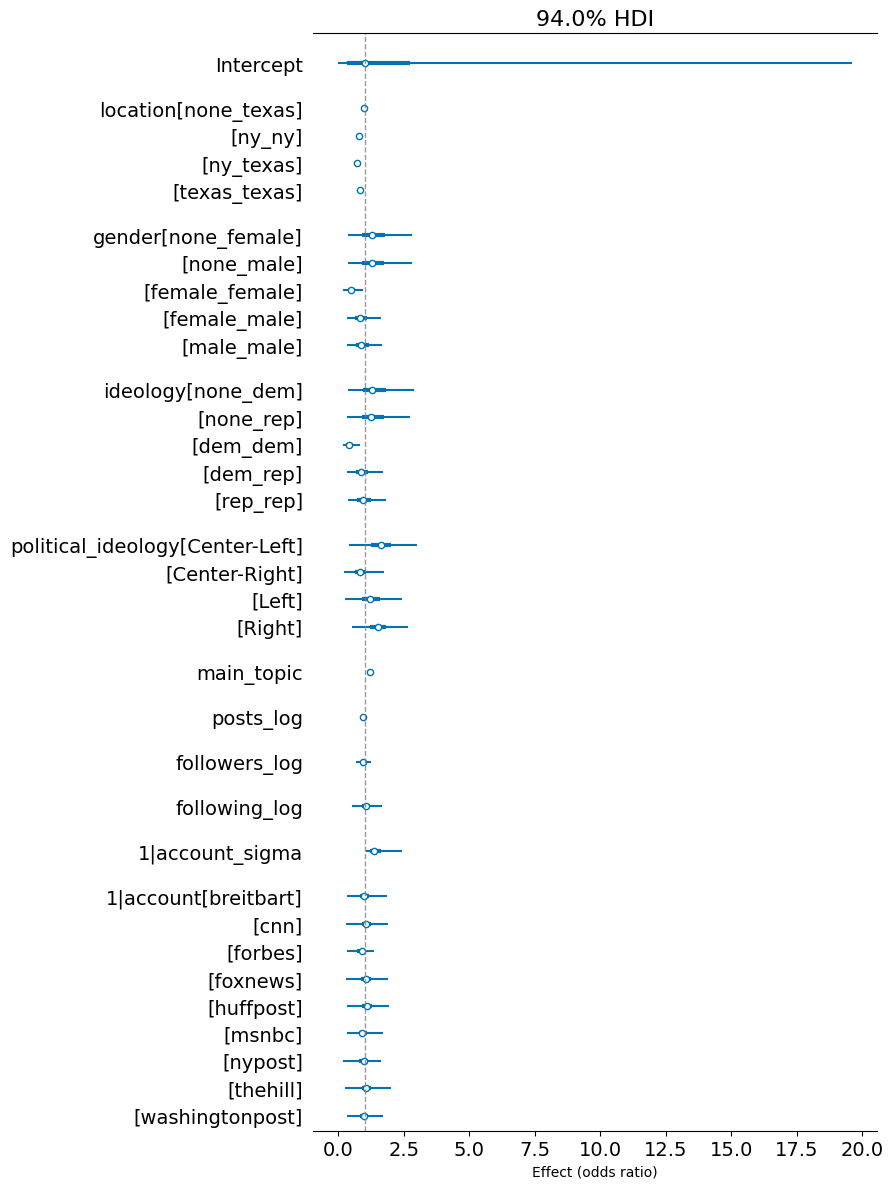

In [40]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + political_ideology + main_topic + posts_log + followers_log + following_log + (1|account)",
    data=reg_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 12),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [Intercept, location, ideology, political_ideology, main_topic, posts_log, followers_log, following_log, 1|account_sigma, 1|account_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1473 seconds.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,1.040,2.860,-3.642,4.544,1.026,0.109,8.0,37.0,1.39
location[none_texas],-0.095,0.153,-0.351,0.050,0.074,0.040,7.0,25.0,1.53
location[ny_ny],0.006,0.424,-0.295,0.739,0.211,0.121,7.0,28.0,1.53
location[ny_texas],-0.029,0.561,-0.405,0.941,0.280,0.161,7.0,12.0,1.58
location[texas_texas],-0.202,0.076,-0.319,-0.106,0.034,0.015,7.0,20.0,1.54
ideology[none_dem],0.463,0.073,0.360,0.566,0.030,0.011,7.0,12.0,1.53
ideology[none_rep],0.285,0.295,-0.220,0.521,0.146,0.082,7.0,19.0,1.55
ideology[dem_dem],-0.723,0.725,-1.238,0.527,0.360,0.207,7.0,11.0,1.59
ideology[dem_rep],-0.320,0.212,-0.515,0.038,0.103,0.057,7.0,20.0,1.56
ideology[rep_rep],-0.234,0.156,-0.403,0.020,0.074,0.038,7.0,13.0,1.58


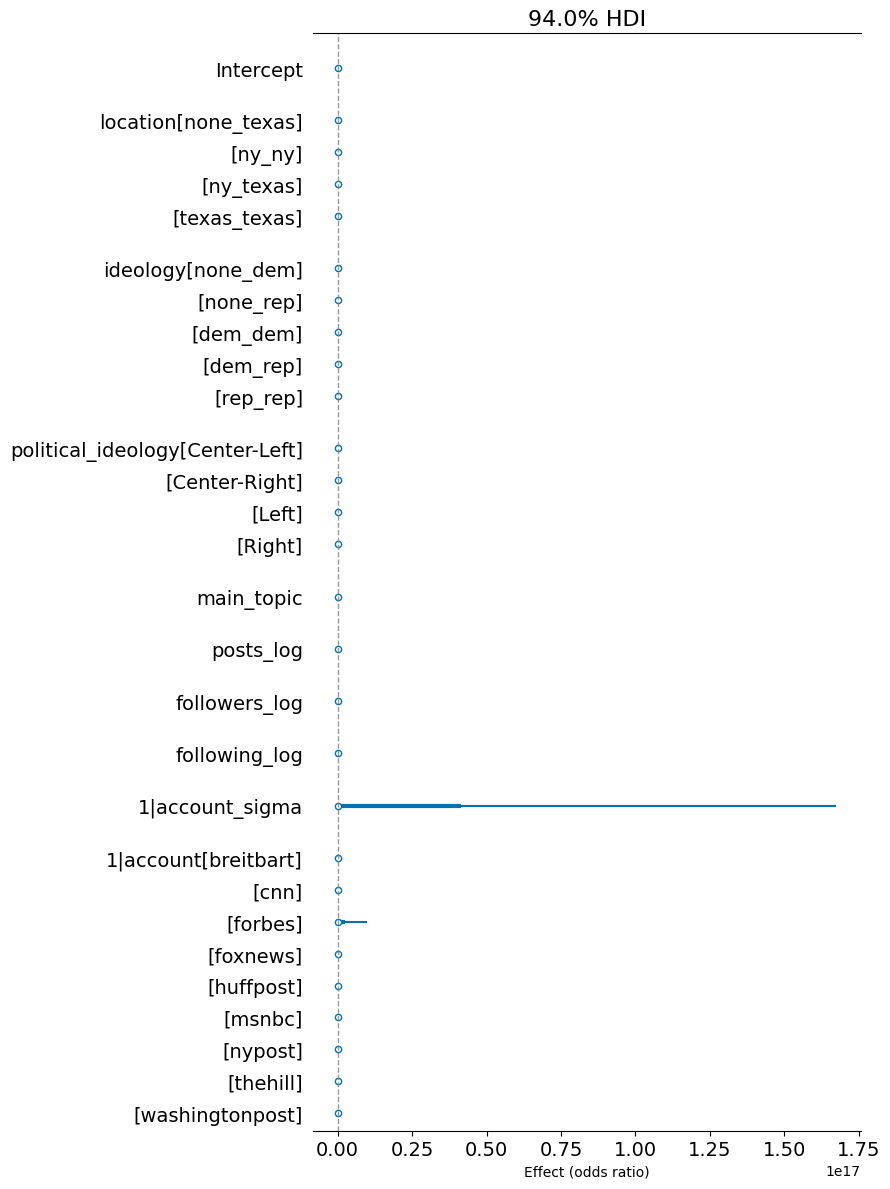

In [39]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + ideology + political_ideology + main_topic + posts_log + followers_log + following_log + (1|account)",
    data=reg_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 12),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [Intercept, location, ideology, main_topic, posts_log, followers_log, following_log, 1|account_sigma, 1|account_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 751 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.197,2.019,-4.878,2.786,0.028,0.042,5667.0,4130.0,1.0
location[none_texas],-0.009,0.042,-0.085,0.071,0.000,0.000,7304.0,5850.0,1.0
location[ny_ny],-0.238,0.041,-0.318,-0.165,0.001,0.000,6135.0,6481.0,1.0
location[ny_texas],-0.353,0.037,-0.426,-0.287,0.000,0.000,6014.0,6063.0,1.0
location[texas_texas],-0.163,0.040,-0.240,-0.089,0.001,0.000,6391.0,6570.0,1.0
ideology[none_dem],0.498,0.047,0.410,0.587,0.001,0.001,4464.0,4609.0,1.0
ideology[none_rep],0.454,0.047,0.365,0.540,0.001,0.000,4404.0,5473.0,1.0
ideology[dem_dem],-1.140,0.068,-1.268,-1.011,0.001,0.001,5679.0,5756.0,1.0
ideology[dem_rep],-0.439,0.052,-0.532,-0.337,0.001,0.001,4581.0,5539.0,1.0
ideology[rep_rep],-0.318,0.058,-0.424,-0.206,0.001,0.001,4854.0,5174.0,1.0


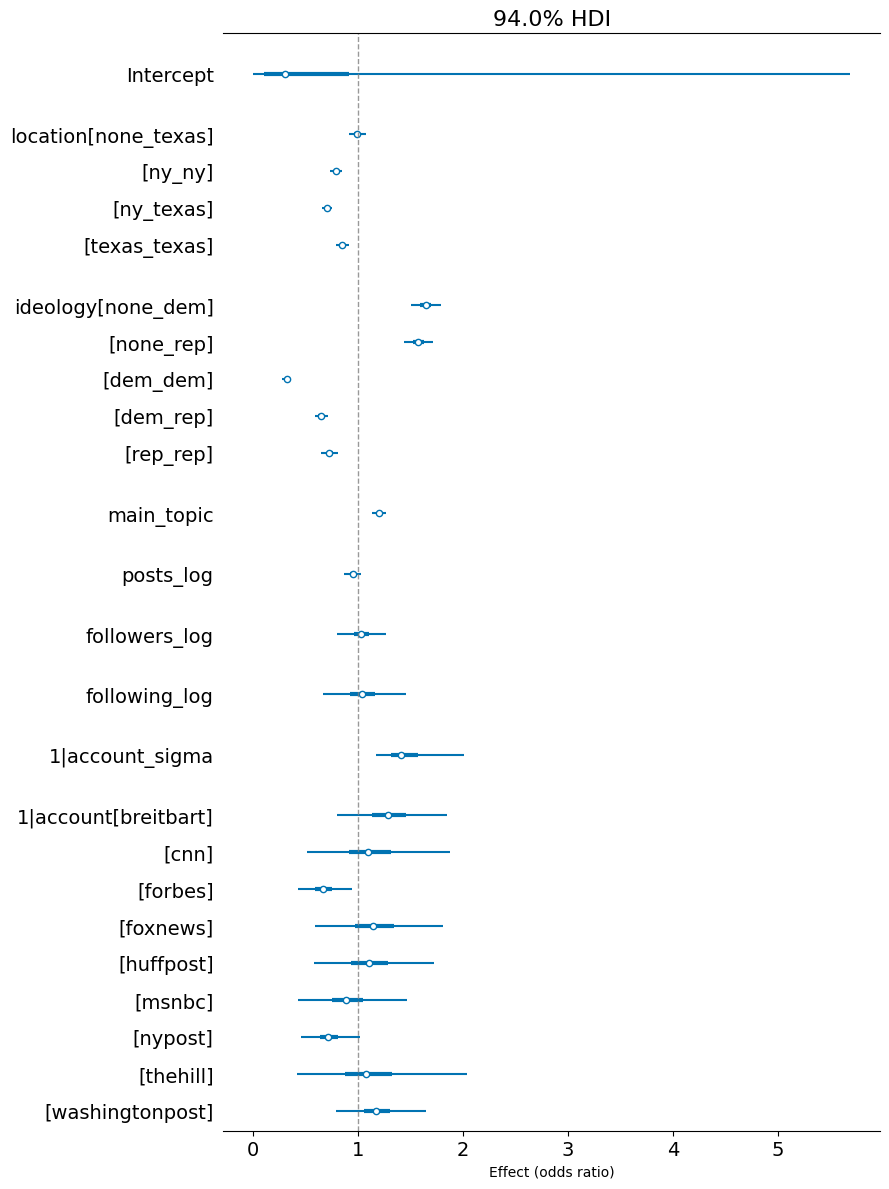

In [40]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + ideology + main_topic + posts_log + followers_log + following_log + (1|account)",
    data=reg_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 12),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")

plt.tight_layout()
plt.show()